In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [186]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [187]:
import warnings
warnings.filterwarnings('ignore')

In [188]:
#5	17	0.1	1.00	-0.75	

In [189]:
#1.2	60	0.3	0.6	1.0	-1.0	

In [190]:
margin_for_trading=1.2

max_secs_between_trades=30
cluster_trade_num_threshold=5
min_price_movement=0.1

burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6

take_profit=0.5
stop_loss=-0.4

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

# OOT part - Jan, Feb 

## Data preparation

In [191]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_ttf_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem1_oot_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

In [192]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [193]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [194]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [195]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
150,150,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0,4.907745
151,151,2024-01-02 09:00:02.000000000,NaN,NaN,91.96,92.50,92.230,1,1.092255
152,152,2024-01-02 09:00:30.000000000,NaN,NaN,91.96,92.49,92.225,1,28.000000
153,153,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0,10.962117
154,154,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0,0.142153


In [196]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
739,739,2024-01-02 09:00:01,NaN,NaN,32.605,32.745,32.6750,1
740,740,2024-01-02 09:00:03,NaN,NaN,32.580,32.745,32.6625,1
741,741,2024-01-02 09:00:05,NaN,NaN,32.580,32.735,32.6575,1
742,742,2024-01-02 09:00:06,NaN,NaN,32.585,32.735,32.6600,1
743,743,2024-01-02 09:00:07,NaN,NaN,32.580,32.725,32.6525,1


## Parameters and calculations

In [197]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(12)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['margin_for_trading'] = margin_for_trading

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [198]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

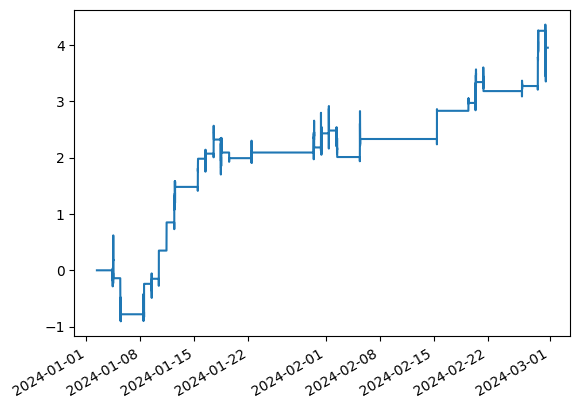

In [199]:
xx.plot()

In [200]:
#df[0:50]

In [201]:
xx[-1:]

2024-02-29 17:59:59    3.95
dtype: float64

# OOT part - Mar,Apr

## Data preparation

In [202]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_ttf_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem1_oot_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

In [203]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [204]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [205]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.day!=10 or x.month==3)]

In [206]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [207]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
538,538,2024-03-01 09:00:00.000000000,NaN,NaN,56.41,56.61,56.510,1,2.00000
539,539,2024-03-01 09:00:05.000000000,NaN,NaN,56.41,56.62,56.515,1,5.00000
540,540,2024-03-01 09:00:09.000000000,NaN,NaN,56.41,56.61,56.510,1,4.00000
541,541,2024-03-01 09:00:09.338750124,56.41,2.0,56.41,56.61,56.510,0,0.33875
542,542,2024-03-01 09:00:10.000000000,NaN,NaN,56.29,56.61,56.450,1,0.66125


In [208]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1149,1149,2024-03-01 09:00:00,NaN,NaN,25.425,25.495,25.4600,1
1150,1150,2024-03-01 09:00:01,NaN,NaN,25.450,25.500,25.4750,1
1151,1151,2024-03-01 09:00:02,NaN,NaN,25.440,25.495,25.4675,1
1152,1152,2024-03-01 09:00:03,NaN,NaN,25.455,25.500,25.4775,1
1153,1153,2024-03-01 09:00:04,NaN,NaN,25.440,25.495,25.4675,1


## Parameters and calculations

In [209]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['margin_for_trading'] = margin_for_trading

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [210]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['price_level']=df['price_level']-df['position']*br_fee

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

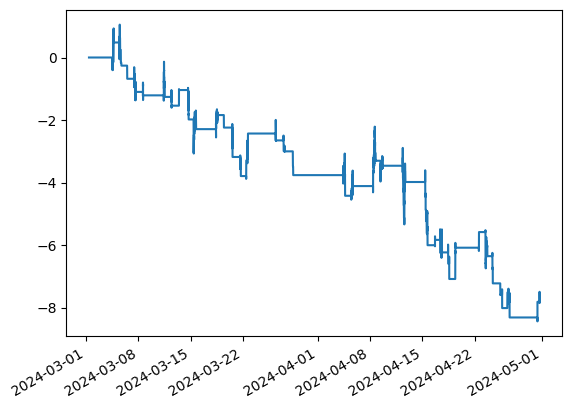

In [211]:
xx.plot()

In [212]:
#df[0:50]

In [213]:
xx[-1:]

2024-04-30 17:59:46   -7.79
dtype: float64

# OOT part - May, Jun

## Data preparation

In [214]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_ttf_may_june.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

In [215]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [216]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [217]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [218]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [219]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
3,3,2024-05-01 09:41:33,NaN,NaN,65.00,67.0,66.000,1,3054.0
4,4,2024-05-01 10:29:43,NaN,NaN,65.00,66.0,65.500,1,2890.0
5,5,2024-05-01 10:29:52,NaN,NaN,65.00,67.0,66.000,1,9.0
6,6,2024-05-01 10:55:13,NaN,NaN,65.25,67.0,66.125,1,1521.0
7,7,2024-05-01 11:35:24,NaN,NaN,65.50,67.0,66.250,1,2411.0


In [220]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1616,1616,2024-05-01 14:33:38,NaN,NaN,NaN,28.625,28.625,1
1617,1617,2024-05-01 14:33:39,NaN,NaN,NaN,28.625,28.625,1
1618,1618,2024-05-01 14:33:40,NaN,NaN,NaN,28.625,28.625,1
1619,1619,2024-05-01 14:33:41,NaN,NaN,NaN,28.625,28.625,1
1620,1620,2024-05-01 14:33:42,NaN,NaN,NaN,28.625,28.625,1


## Parameters and calculations

In [221]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['margin_for_trading'] = margin_for_trading

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [222]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

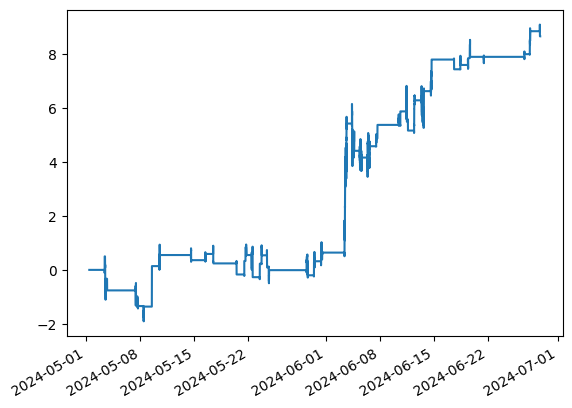

In [223]:
xx.plot()

In [224]:
#df[0:50]

In [225]:
xx[-1:]

2024-06-28 17:59:58    8.65
dtype: float64

# Production check

## Data preparation

In [226]:
# data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_production_sample.csv',
#                     parse_dates=['datetime']).reset_index()

# data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_production_sample.csv',
#                     parse_dates=['datetime']).reset_index()

In [227]:
# data_lead['datetime'] = pd.to_datetime(data_lead['datetime'], errors='coerce')
# data_lag['datetime'] = pd.to_datetime(data_lag['datetime'], errors='coerce')

In [228]:
# data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [229]:
# data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
# data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [230]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [231]:
# data_lag.head()

In [232]:
# data_lead.head()

## Parameters and calculations

In [233]:
# instr = 'm2'

# contr_vars = []

# param_list = ['t_end', 'take_profit', 'stop_loss']
# param_dict = {k: [] for k in param_list}
# param_dict['t_end'] = time(17)
# param_dict['take_profit'] = take_profit
# param_dict['stop_loss'] = stop_loss
# param_dict['ba_max']=0.3

# param_dict['br_fee'] = br_fee

# param_dict['max_secs_between_trades'] = max_secs_between_trades
# param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
# param_dict['min_price_movement'] = min_price_movement

# param_dict['margin_for_trading'] = margin_for_trading

# param_dict['burnout_period']=burnout_period
# param_dict['stop_profit']=stop_profit
# param_dict['makeagg_ratio']=makeagg_ratio

# vol_class = VolumeClass(1, {'max_clips': 1})
# backtest_class = BacktestLL(vol_class)
# # model_class = HawkesIntensity
# strategy_class = StrategyLL(
#                             strategy='LL',
#                             market='de',
#                             instrument=instr, 
#                             is_overnight=False,
#                             closing_mode=closing_mode)

# strategy_class.load_params(param_dict, contr_vars)

# xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

# df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
# df = pd.concat([df, ])

## Results

In [234]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # As

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

In [235]:
# xx.plot()

In [236]:
#df[0:50]

In [237]:
# xx[-1:]

In [238]:
# xx

# Checking orderbooks

In [239]:
# #!/usr/bin/env python3
# # -*- coding: utf-8 -*-
# """
# Created on Sat Aug 26 15:21:20 2023

# @author: marek
# """

# from datetime import datetime
# from Database.TPData import TPData, TPDataDa
# from OrderBook.OrderBook import OrderBookSnaps
# import pandas as pd

# l_path = '//192.168.10.91/data/Data/orderbooks/base/'


# def load_ob(m, t, dt, p_d, bT, eT):
#     ob_class = OrderBookSnaps(verbose=True)
#     file_path = l_path + t.split('_')[0] + '/'
#     file_name = m + '_' + t.split('_')[0] + '_' + p_d.strftime('%y%m%d') + '_' + dt.strftime('%y%m%d') + '.p'
#     print(('%s Loading OrderBook %d...' % (dt.strftime('%y-%m-%d'), 0)))
#     time_load = ob_class.import_data(file_path + file_name)
#     print(('OrderBook %d created in %d sec' % (0, time_load)))
#     # ob_class.LoB_truncate(thres_vol=1)
#     return ob_class.LoB_select(bT, eT, freq=None)


# mkt = 'de'
# tenor = 'y'
# prod = 'base'
# venue_list = ['eex']
# start_date1 = datetime(2025, 1, 1)
# start_date2 = None
# bT = datetime(2024, 6, 20, hour=8, minute=0, second=0)
# eT = datetime(2024, 6, 20, hour=18, minute=0, second=0)

# is_calc = False
# is_db = True

# if is_db:
#     data_class = TPData()
#     data_class.create_connection('PostgreSQL')
# else:
#     data_class = TPDataDa()

# ob_class = OrderBookSnaps(verbose=True)
# if is_db:
#     if is_calc:
#         df_ord_data = data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                                  bT, eT, prod, start_date2)
        
#         LoB_dict, err_dict = ob_class.construct_data(df_ord_data)
#     else:
#         LoB_dict, time_list = load_ob(mkt, tenor, bT, start_date1, bT, eT)
#         ob_class.update_data(LoB_dict, time_list)
# else:
#     df_ord_data = data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                              bT, eT, prod, start_date2)
#     ob_class.import_from_tp(df_ord_data)
    

# df_ba_data = data_class.get_best_orders_data(mkt, tenor, start_date1, bT, eT,
#                                              prod, start_date2)

# data_class = TPDataDa()
# df_ba_data1 = data_class.get_best_ob_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

# ax = pd.concat([ob_class.best_bid_all, ob_class.best_ask_all], axis=1).plot()
# df_ba_data1.plot(ax=ax)

In [240]:
# xx = pd.concat([ob_class.best_bid_all, ob_class.best_ask_all], axis=1)
# xx.columns = ['bidbestprice', 'askbestprice']
# xx1 = data_class.process_best_orders(xx)

In [241]:

# xx1.reset_index()

In [242]:
# start_time = '2024-06-20 10:27:04'
# end_time = '2024-06-20 10:27:09'

# a=df_ba_data1.reset_index()

# a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]

In [243]:
# df=data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

In [244]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# a=df.reset_index()

# type(a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]['bids'][31920][0])

In [245]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# ob_class.LoB_dict[130000].bids[1].po_id